In [2]:
import numpy as np
import tensorflow as tf
from tqdm import tqdm

# ==============================================================================
# 설정 파라미터 (논문 기준)
# ==============================================================================
BANDWIDTH = 15e6            # 15 MHz
NUM_SUBCARRIERS = 64        # 논문의 61개에 근사한 2의 제곱수 (FFT 효율성)
INPUT_SEQ_LEN = 10          # 과거 10개 프레임 입력
PRED_SEQ_LEN = 10           # 미래 10개 프레임 예측

def preprocess_channel_data(file_path):
    print("🔄 데이터 로드 및 전처리 시작...")
    data = np.load(file_path, allow_pickle=True)
    
    frequencies = np.linspace(-BANDWIDTH/2, BANDWIDTH/2, NUM_SUBCARRIERS)
    
    processed_bursts = []
    
    for burst in tqdm(data, desc="Processing Bursts"):
        # Burst 내부 데이터 추출
        a_list = burst['a']      # List of snapshots
        tau_list = burst['tau']  # List of snapshots
        
        h_time_series = []
        
        for i in range(len(a_list)):
            # 1. 데이터 형상 복원 (Real/Imag 분리된 것 합치기)
            # 저장된 a 형상: (2, 1, 1, 3, 1, Paths) -> 첫 차원이 (Real, Imag)
            a_raw = a_list[i]
            tau_raw = tau_list[i] # (1, 3, Paths)
            
            if a_raw.size == 0: # 경로가 없는 경우 0으로 채움
                h_freq = np.zeros((1, 1, 3, 1, NUM_SUBCARRIERS), dtype=np.complex64)
                h_time_series.append(h_freq)
                continue

            # 복소수 변환: Real + 1j * Imag
            a_complex = a_raw[0] + 1j * a_raw[1] # Shape: (1, 1, 3, 1, Paths)
            
            # 차원 맞추기 (Broadcasting 준비)
            # a_complex: (Batch, Rx, RxAnt, Tx, TxAnt, Paths)
            # tau_raw  : (Batch, Tx, Paths) -> (Batch, 1, 1, Tx, 1, Paths) 로 확장 필요
            tau_expanded = tau_raw[:, None, None, :, None, :]
            
            # 2. 주파수 응답 H(f) 계산
            # H(f) = sum( a * exp(-j * 2pi * f * tau) )
            
            # 주파수 그리드 확장
            freq_grid = frequencies[None, None, None, None, None, None, :] # (..., 64)
            tau_grid = tau_expanded[..., None]                             # (..., 1)
            a_grid = a_complex[..., None]                                  # (..., 1)
            
            phase = -1j * 2 * np.pi * tau_grid * freq_grid
            transfer_func = a_grid * np.exp(phase)
            
            # 경로(Path) 차원에 대해 합산 -> 채널 행렬 H 완성
            h_freq = np.sum(transfer_func, axis=-2) # Paths 차원(-2) 합산
            h_time_series.append(h_freq)
            
        # 하나의 Burst에 대한 시계열 데이터 (30, Batch, Rx, RxAnt, Tx, TxAnt, Subcarriers)
        processed_bursts.append(np.array(h_time_series))
        
    print("✅ 채널 변환 완료.")
    return processed_bursts

def create_dataset(processed_bursts):
    # 슬라이딩 윈도우로 데이터셋 생성
    # 입력: [t, t+1, ..., t+9] -> 정답: [t+10, ..., t+19]
    X_list = []
    Y_list = []
    
    for burst in processed_bursts:
        # burst shape: (30, 1, 1, 1, 3, 1, 64) -> 불필요 차원 제거
        # Target shape: (30, Subcarriers, Tx*Rx*Ant...) 등으로 평탄화 필요
        # 여기서는 간단히 (30, Features) 형태로 만듭니다.
        # Features = Rx(1)*RxAnt(1)*Tx(3)*TxAnt(1)*Subcarriers(64) = 192
        
        # Squeeze & Flatten
        burst_flat = burst.reshape(30, -1) # (Time, Features)
        
        num_snapshots = len(burst_flat)
        total_window = INPUT_SEQ_LEN + PRED_SEQ_LEN
        
        if num_snapshots < total_window:
            continue
            
        for i in range(num_snapshots - total_window + 1):
            x_seq = burst_flat[i : i + INPUT_SEQ_LEN]
            y_seq = burst_flat[i + INPUT_SEQ_LEN : i + total_window]
            X_list.append(x_seq)
            Y_list.append(y_seq)
            
    return np.array(X_list), np.array(Y_list)

# 실행 예시
bursts = preprocess_channel_data('channel_history_burst.npy')
X, Y = create_dataset(bursts)
print(f"Dataset Created: X shape {X.shape}, Y shape {Y.shape}")
# X shape 예상: (샘플수, 10, 192) - 복소수 데이터

🔄 데이터 로드 및 전처리 시작...


Processing Bursts: 100%|██████████| 20/20 [00:00<00:00, 1142.92it/s]

✅ 채널 변환 완료.
Dataset Created: X shape (220, 10, 192), Y shape (220, 10, 192)


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

class SEBlock(layers.Layer):
    def __init__(self, filters, ratio=16):
        super(SEBlock, self).__init__()
        self.avg_pool = layers.GlobalAveragePooling1D()
        self.dense1 = layers.Dense(filters // ratio, activation='relu', use_bias=False)
        self.dense2 = layers.Dense(filters, activation='sigmoid', use_bias=False)

    def call(self, inputs):
        # inputs shape: (batch, time, features)
        # SE block usually applies to feature/channel dimension
        se = self.avg_pool(inputs)      # (batch, features)
        se = self.dense1(se)
        se = self.dense2(se)            # (batch, features)
        se = layers.Reshape((1, -1))(se) # (batch, 1, features) for broadcasting
        return inputs * se

def build_se_lstm_model(input_shape, output_len):
    # input_shape: (Time_Steps, Features)
    # Features는 실수부/허수부를 합쳐서 2배가 되거나, 복소수 자체를 처리해야 함
    
    inputs = layers.Input(shape=input_shape)
    
    # 1. Feature Extraction (Optional Dense/Conv layer)
    x = layers.Dense(256, activation='relu')(inputs)
    
    # 2. LSTM Layer 1
    x = layers.LSTM(256, return_sequences=True)(x)
    
    # 3. SE Block 적용 (Feature recalibration)
    # LSTM 출력의 Feature 차원에 대해 중요도 계산
    x = SEBlock(256, ratio=16)(x)
    
    # 4. LSTM Layer 2
    x = layers.LSTM(256, return_sequences=False)(x) # 마지막 state만 사용? 
    # 논문은 Seq2Seq 구조이므로 Decoder가 필요하거나, 
    # RepeatVector를 사용해 미래 시퀀스를 생성해야 함.
    
    # 예측을 위한 Decoder 구조 (Repeat -> LSTM)
    x = layers.RepeatVector(output_len)(x)
    x = layers.LSTM(256, return_sequences=True)(x)
    
    # 5. Output Layer
    # 원래 Feature 크기로 복원
    outputs = layers.TimeDistributed(layers.Dense(input_shape[-1]))(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name="SE_LSTM")
    return model

# 모델 생성 예시
# 데이터가 복소수이므로 실수형으로 변환 (Feature 차원 2배 확장)
X_real = np.concatenate([X.real, X.imag], axis=-1) # (Sample, 10, 384)
Y_real = np.concatenate([Y.real, Y.imag], axis=-1)

model = build_se_lstm_model(input_shape=(10, X_real.shape[-1]), output_len=10)
model.compile(optimizer='adam', loss='mse')
model.summary()

# 학습 시작
# history = model.fit(X_real, Y_real, epochs=50, batch_size=32, validation_split=0.2)

I0000 00:00:1767085070.855060  146332 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1041 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:81:00.0, compute capability: 8.6
I0000 00:00:1767085070.856508  146332 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22059 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:c1:00.0, compute capability: 8.6


Model: "SE_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 384)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 256)        │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ se_block (SEBlock)              │ (None, 10, 256)        │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 256)        │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 384)        │        98,688 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,781,376 (6.80 MB)

 Trainable params: 1,781,376 (6.80 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(X_real, Y_real, epochs=500, batch_size=16, validation_split=0.2)

Epoch 1/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.7836e-10 - val_loss: 1.3890e-10
Epoch 2/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 7.9980e-11 - val_loss: 9.9954e-11
Epoch 3/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 4.9753e-09 - val_loss: 3.0128e-09
Epoch 4/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4.1983e-09 - val_loss: 9.3754e-10
Epoch 5/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.5000e-09 - val_loss: 1.9091e-10
Epoch 6/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 4.2463e-09 - val_loss: 1.0954e-08
Epoch 7/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 4.7038e-09 - val_loss: 1.8784e-09
Epoch 8/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.7722e-09 - val_loss: 1.1686e-09
Epoch 9/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 7.3729e-09 - val_loss: 4.7611e-09
Epoch 10/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4.2423e-09 - val_loss: 2.7834e-09
Epoch 11/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss

🔮 채널 예측 수행 중...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

📊 평가 결과:
 - MSE: 3.985102e-09
 - MAE: 5.470231e-05


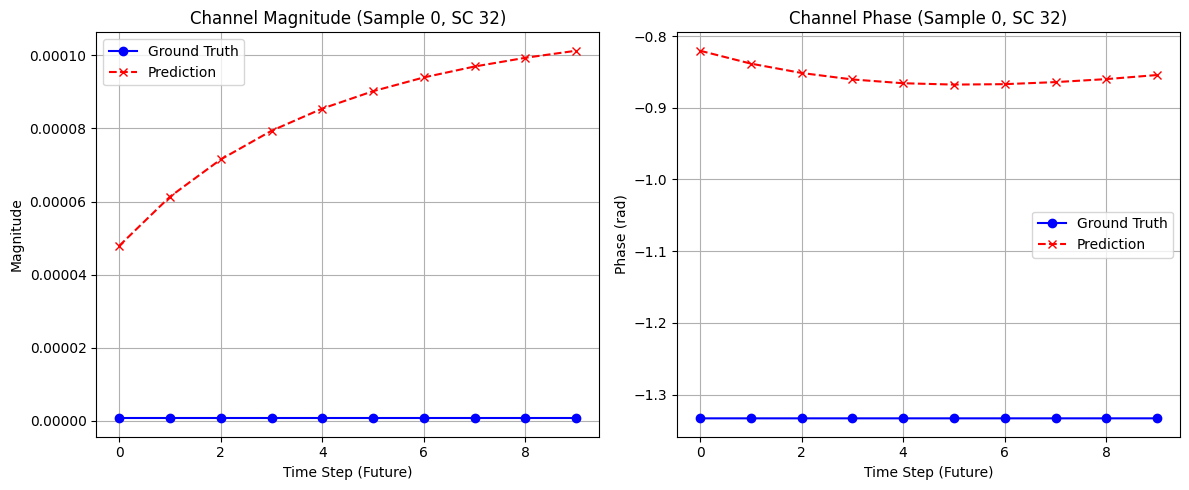

In [6]:
import matplotlib.pyplot as plt

# 1. 예측 수행 (Predict)
# 테스트 데이터(X_test)가 따로 없다면, 검증 데이터나 전체 데이터의 일부를 사용합니다.
# 여기서는 학습에 사용된 X를 그대로 사용하여 시연합니다. (실제 연구에선 Test Set 분리 필요)
print("🔮 채널 예측 수행 중...")
Y_pred_real = model.predict(X_real)

# 2. 복소수 형태로 복원 (Real + j*Imag)
# Y_real 형태: (Samples, 10, 384) -> 앞쪽 절반이 실수, 뒤쪽 절반이 허수
feature_dim = Y_real.shape[-1] // 2
Y_true_complex = Y_real[..., :feature_dim] + 1j * Y_real[..., feature_dim:]
Y_pred_complex = Y_pred_real[..., :feature_dim] + 1j * Y_pred_real[..., feature_dim:]

# 3. 성능 지표 계산 (MSE, MAE)
# 논문 기준: Magnitude(절댓값) 또는 복소수 거리 기반 오차
mse = np.mean(np.abs(Y_true_complex - Y_pred_complex)**2)
mae = np.mean(np.abs(Y_true_complex - Y_pred_complex))

print(f"\n📊 평가 결과:")
print(f" - MSE: {mse:.6e}")
print(f" - MAE: {mae:.6e}")

# 4. 시각화 (Visualization)
# 특정 샘플, 특정 부반송파의 시간 흐름에 따른 변화 비교
sample_idx = 0      # 보고 싶은 샘플 인덱스
subcarrier_idx = 32 # 보고 싶은 부반송파 인덱스 (중간 대역)

# 데이터 추출 (Samples, Time, Features) -> Features를 다시 (Rx, Tx, Subcarrier)로 해석해야 함
# 현재 Features는 Flatten된 상태이므로, Subcarrier 차원을 찾아야 합니다.
# 1x1 SISO 기준 Features = 64 (Subcarriers)
# 만약 안테나가 늘어나면 인덱싱 주의 필요. 여기서는 SISO 가정.

true_seq = Y_true_complex[sample_idx, :, subcarrier_idx]
pred_seq = Y_pred_complex[sample_idx, :, subcarrier_idx]

plt.figure(figsize=(12, 5))

# Magnitude 비교
plt.subplot(1, 2, 1)
plt.plot(np.abs(true_seq), 'b-o', label='Ground Truth')
plt.plot(np.abs(pred_seq), 'r--x', label='Prediction')
plt.title(f'Channel Magnitude (Sample {sample_idx}, SC {subcarrier_idx})')
plt.xlabel('Time Step (Future)')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True)

# Phase 비교
plt.subplot(1, 2, 2)
plt.plot(np.angle(true_seq), 'b-o', label='Ground Truth')
plt.plot(np.angle(pred_seq), 'r--x', label='Prediction')
plt.title(f'Channel Phase (Sample {sample_idx}, SC {subcarrier_idx})')
plt.xlabel('Time Step (Future)')
plt.ylabel('Phase (rad)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()